# Step 1 : Introduction to CNNs

## Imports

In [10]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

## Tools / functions

In [53]:
def display_image(dataset, classes):
    plt.figure(figsize=(10, 10))
    for images, labels in dataset.take(2):
        for i in range(2):
            ax = plt.subplot(1, 2, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(classes[labels[i]])
            plt.axis("off")

# Step 2: Dataset Exploration

In [55]:
# Parameters
batch_size = 10
data_dir = 'cats_and_dogs_filtered'
validation_split=0.2

In [56]:
# load the dataset
train = tf.keras.utils.image_dataset_from_directory(
  data_dir+"/train",
  validation_split=validation_split,
  subset="training",
  seed=342,
  batch_size=batch_size,
  image_size=(256,256),
  interpolation="bilinear")

validation = tf.keras.utils.image_dataset_from_directory(
  data_dir+"/validation",
  seed=342,
  batch_size=batch_size,
  image_size=(256,256),
  interpolation="bilinear")

Found 2000 files belonging to 2 classes.
Using 1600 files for training.
Found 1000 files belonging to 2 classes.


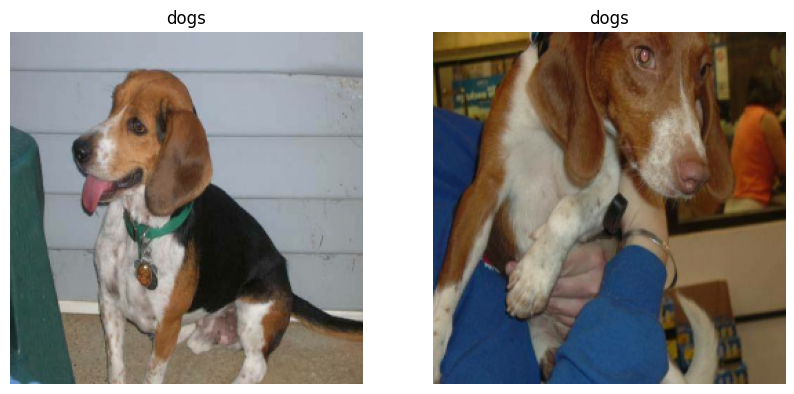

In [58]:
display_image(train,train.class_names)

# Step 3: Build Your CNN Model

In [ ]:
# Model Parameters

A lot of help was found from this [site](https://www.tensorflow.org/tutorials/load_data/images)

In [83]:

# Build the MLP
model = Sequential([
    #Scaling the RGB values to be from 0 to 1
    tf.keras.layers.Rescaling(1./255, name="Scaling_layer", input_shape=(256,256,3)),
    #First Convolution/Pooling layer
    tf.keras.layers.Conv2D(32,(3,3),strides=(1, 1), padding='same',dilation_rate=(1, 1), activation='relu', use_bias=True, name="Convolution_1"),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=None, padding='valid', name="downsizing_1",),

    #Second Convolution/Pooling layer
    tf.keras.layers.Conv2D(32,(3,3), strides=(1, 1), padding='same',dilation_rate=(1, 1), activation='relu', use_bias=True, name="Convolution_2"),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=None, padding='valid', name="downsizing_2",),

    #Third Convolution/Pooling layer
    tf.keras.layers.Conv2D(32,(3,3), strides=(1, 1), padding='same',dilation_rate=(1, 1), activation='relu', use_bias=True, name="Convolution_3"),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=None, padding='valid', name="downsizing_3",),

    #Fourth and final Convolution/Pooling layer
    tf.keras.layers.Conv2D(64,(3,3), strides=(1, 1), padding='same',dilation_rate=(1, 1), activation='relu', use_bias=True, name="Convolution_4"),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=None, padding='valid', name="downsizing_4",),

    # Finish
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(8, activation='relu'),

    #Dense layer and output
    Dense(2, activation='relu',  name="output_layer"),
    tf.keras.layers.Softmax(name="output_function"),
])

# Compile the model
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate =0.1),
    # Loss function to minimize
    loss='SparseCategoricalCrossentropy',
    #loss='mse',
    # List of metrics to monitor
    metrics=['accuracy']
)

# Display the architecture
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Scaling_layer (Rescaling)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolution_1 (Conv2D)          │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ downsizing_1 (MaxPooling2D)     │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolution_2 (Conv2D)          │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ downsizing_2 (MaxPooling2D)     │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolution_3 (Conv2D)          │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ downsizing_3 (MaxPooling2D)     │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Convolution_4 (Conv2D)          │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ downsizing_4 (MaxPooling2D)     │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │       131,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_function (Softmax)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,986 (660.10 KB)

 Trainable params: 168,986 (660.10 KB)

 Non-trainable params: 0 (0.00 B)

# Step 4: Train the Model

In [ ]:
model.fit(
    train,
    epochs=8,
)

Epoch 1/8
107/160 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.5079 - loss: 1507.0406

# Step 5: Evaluate the Model on the test set

In [73]:
def get_predicted_label(prediction):
    predicted_label = [0 if pred<0.5 else 1 for pred in prediction]
    return predicted_label

def label_transform(label):
    transformed = [ np.array([0,1]) if labe==1 else np.array([1,0]) for labe in label]
    return transformed

In [80]:
results = model.evaluate(validation)
print("test loss, test acc:", results)

InvalidArgumentError: Graph execution error:

Detected at node compile_loss/mse/sub defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "c:\Users\alexi\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "c:\Users\alexi\AppData\Local\Programs\Python\Python312\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "c:\Users\alexi\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start

  File "c:\Users\alexi\AppData\Local\Programs\Python\Python312\Lib\site-packages\tornado\platform\asyncio.py", line 211, in start

  File "c:\Users\alexi\AppData\Local\Programs\Python\Python312\Lib\asyncio\base_events.py", line 618, in run_forever

  File "c:\Users\alexi\AppData\Local\Programs\Python\Python312\Lib\asyncio\base_events.py", line 1951, in _run_once

  File "

In [74]:
#print(model.predict(validation))
for image, labels in validation.take(1):
    print(label_transform(labels))
    accuracy = accuracy_score(label_transform(labels) , model.predict(image))
    print("Accuracy on data = {:.2f}%".format(100 * accuracy))

[array([1, 0]), array([0, 1]), array([0, 1]), array([1, 0]), array([1, 0]), array([1, 0]), array([1, 0]), array([1, 0]), array([1, 0]), array([1, 0])]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


ValueError: Classification metrics can't handle a mix of multilabel-indicator and continuous-multioutput targets

# Step 6: Try to Improve the Model

# Bonus Challenge: Transfer Learning